In [1]:
# 1. Imports
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.models import resnet50, ResNet50_Weights

from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 2. Load pretrained CNN
device = "cuda" if torch.cuda.is_available() else "cpu"

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).to(device)
model.eval()

preprocess = weights.transforms()
categories = weights.meta["categories"]

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


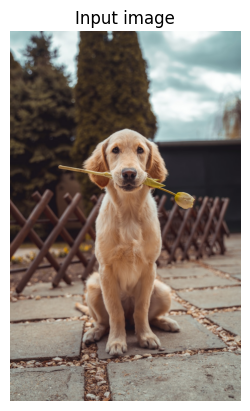

In [3]:
# 3. Load a dog image
url = "https://images.unsplash.com/photo-1552053831-71594a27632d?w=800"
image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.title("Input image")
plt.show()

In [4]:
# 4. Predict class
input_tensor = preprocess(image).unsqueeze(0).to(device)

output = model(input_tensor)
probs = F.softmax(output, dim=1)

class_idx = probs.argmax().item()
class_name = categories[class_idx]
confidence = probs[0, class_idx].item()

print(f"Prediction: {class_name}")
print(f"Confidence: {confidence:.2%}")

Prediction: golden retriever
Confidence: 45.12%


In [5]:
# 5. Grad-CAM setup
activations = None
gradients = None

target_layer = model.layer4[-1]

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [6]:
# 6. Run Grad-CAM
model.zero_grad()

output = model(input_tensor)
score = output[0, class_idx]
score.backward()

# Average gradients across width and height
weights_grad = gradients.mean(dim=(2, 3), keepdim=True)

# Weighted sum of activation maps
cam = (weights_grad * activations).sum(dim=1, keepdim=True)
cam = F.relu(cam)

# Normalize heatmap
cam = cam.squeeze().detach().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min())

# Resize to original image size
cam_img = Image.fromarray(np.uint8(cam * 255)).resize(image.size)
cam = np.array(cam_img) / 255

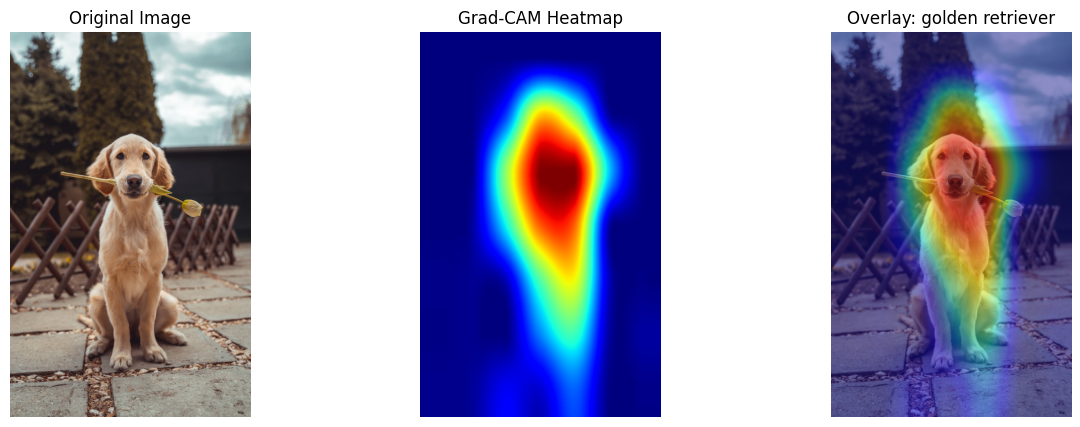

In [7]:
# 7. Show original, heatmap, and overlay
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.axis("off")
plt.title("Grad-CAM Heatmap")

plt.subplot(1, 3, 3)
plt.imshow(image)
plt.imshow(cam, cmap="jet", alpha=0.45)
plt.axis("off")
plt.title(f"Overlay: {class_name}")

plt.show()